In [31]:
import Interactions
import numpy as np
import matplotlib.pyplot as plt

In [32]:
const = Interactions.PhysicalConstants()

In [33]:
AzoTAB_cis = Interactions.Surfactant(
    cmc = 0.82,
    charge_fraction = 0.2, #definitely need to look better into it
    aggregation_number = 72,
    mycel_diameter = 2.5E-9,
    delta = 0.75 #we'll have to sort this out
)

AzoTAB_trans = Interactions.Surfactant(
    cmc = 0.34,
    charge_fraction = 0.2, 
    aggregation_number = 310,
    mycel_diameter= 4.1E-9, 
    delta = 0.75
    
)

CTAC = Interactions.Surfactant(
    cmc = 1.31,
    charge_fraction = 0.28, 
    aggregation_number = 120,
    mycel_diameter= 4.6E-9, 
    delta = 0.75
)


In [50]:
sol = Interactions.SolutionState(
    temperature= 298.0,
    eps_r = 80, # I imagine we're in water
    surfactants=(AzoTAB_cis,AzoTAB_trans),
    layer_thickness = 1.5E-9, #this is related to the screening surfactant
    zeta_pot = 40E-3,
    composition = 1
)

In [48]:
#testing the objects first then how to handle length and bla bla


rod = Interactions.RodSpecies(
    width = 30E-9,
    length = 260E-9,
    hamaker = 40E-20 #Silver
)




42606.61545925041
0.0
[3.475475475475475e-08, -243.85054819328192]
1


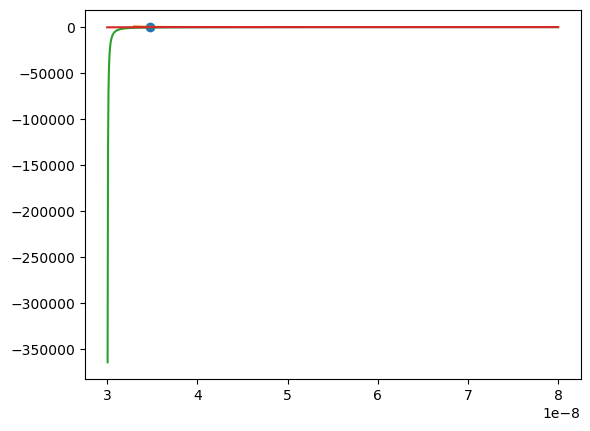

In [52]:
conc = 500
spacing = np.linspace(30E-9, 80E-9, 1000)
vdw = Interactions.VdWInteraction()
el = Interactions.ElectrostaticInteraction()
ao = Interactions.DepletionInteraction()

en_vdw = vdw.energy(rod, rod, spacing)/(const.k_B*sol.temperature)*rod.length
en_el = el.energy(rod, rod, spacing, sol, conc)/(const.k_B*sol.temperature)*rod.length
en_ao = ao.energy(rod, rod, spacing, sol, conc)/(const.k_B*sol.temperature)*rod.length

en_tot =  en_el + en_vdw + en_ao
plt.plot(spacing, en_tot)
plt.plot(spacing, en_el)
plt.plot(spacing, en_vdw)
plt.plot(spacing, en_ao)
min = [spacing[np.argmin(en_tot)], np.min(en_tot)]
print(min)
plt.scatter(min[0], min[1])
print(sol.composition)

#plt.vlines(rod.width+sol.layer_thickness+AzoTAB_trans.mycel_diameter/2., -30, 10)